## Figure 5 — mRNA vaccine cohort

| Panel | Content | Output |
|---|---|---|
| a | AP bar chart (full cohort, all patients pooled) | `fig5_a.pdf` |
| b | mPPV@1–10 per patient — grouped bar chart (4 patients × 6 models) | `fig5_b.pdf` |
| c | PPV@k=1–10 curves — 4 subplots × 6 model lines | `fig5_c.pdf` |
| d | First-hit rank (unfilled bars + per-patient lines) | `fig5_d.pdf` |

Models: ImmunoMTL, BigMHC, MUNIS, PRIME 2.0, netMHCpan 4.1, MHCflurry 2.0
Patients: P10, P11, P25, P29 (4 patients with ≥2 positives)


In [302]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics import roc_auc_score, average_precision_score

_here = os.path.abspath('.')
if os.path.basename(_here) in ('notebook', 'analysis'):
    os.chdir(os.path.dirname(_here))

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype']  = 42
matplotlib.rcParams['font.size']    = 9

FIG_DIR = 'analysis/figures'
os.makedirs(FIG_DIR, exist_ok=True)


In [303]:
# ── Canonical palette & model registry ────────────────────────────────────────

PRED = 'pred_results'

MRNA_MODELS = ['ImmunoMTL', 'BigMHC', 'MUNIS', 'PRIME2', 'netMHCpan', 'MHCflurry']

COLORS = {
    'ImmunoMTL': '#4E526E',
    'STL':       '#E07A5F',
    'ABC':       '#B8A8C8',
    'JointSTL':  '#8BAAB8',
    'Shuffle':   '#D3D3D3',
    'BigMHC':    '#F6D5A0',
    'MUNIS':     '#92BEAA',
    'PRIME2':    '#718B8E',
    'netMHCpan': '#606060',
    'MHCflurry': '#F0C3AF',
}

DISPLAY = {
    'ImmunoMTL': 'ImmunoMTL',
    'BigMHC':    'BigMHC',
    'MUNIS':     'MUNIS',
    'PRIME2':    'PRIME 2.0',
    'netMHCpan': 'netMHCpan 4.1',
    'MHCflurry': 'MHCflurry 2.0',
}

COL_MAP = {
    'ImmunoMTL': ('ImmunoMTL_score',             False),
    'BigMHC':    ('BigMHC_IM',                   False),
    'MUNIS':     ('munis',                        False),
    'PRIME2':    ('PRIME_rank',                   True),
    'netMHCpan': ('netMHCpan_rank',              True),
    'MHCflurry': ('mhcflurry_presentation_rank', True),
}

PATIENTS       = [10, 11, 25, 29]
PLABEL         = {10: 'P10', 11: 'P11', 25: 'P25', 29: 'P29'}
PATIENT_COLORS = ['#ed6a5a', '#335c67', '#9bc1bc', '#fabc3c']
K_MAX          = 10


In [304]:
# ── Load data & compute PPV@k curves ──────────────────────────────────────────
# Base: data/mRNAvaccine_pID.csv (Peptide, MHC, Label, patientID)
# Scores merged in from pred_results/ per model.

_MERGE = [
    # (model_key, file, src_col, dst_col, pep_col, mhc_col)
    ('ImmunoMTL', f'{PRED}/MTL/mRNA_predictions.csv',
     'score',                             'ImmunoMTL_score',             'Peptide', 'MHC'),
    ('BigMHC',    f'{PRED}/bigmhc/mRNA_bigmhc.csv',
     'BigMHC_IM',                         'BigMHC_IM',                   'pep',     'mhc'),
    ('MUNIS',     f'{PRED}/munis/mRNA_munis_predictions.csv',
     'score',                             'munis',                       'pep',     'mhc'),
    ('PRIME2',    f'{PRED}/prime2/mRNA_prime.csv',
     'PRIME_rank',                        'PRIME_rank',                  'Peptide', 'MHC'),
    ('netMHCpan', f'{PRED}/netMHCpan/mRNA_netMHCpan.csv',
     'EL_Rank',                           'netMHCpan_rank',              'Peptide', 'MHC'),
    ('MHCflurry', f'{PRED}/mhcflurry/mRNA_mhcflurry.csv',
     'mhcflurry_presentation_percentile', 'mhcflurry_presentation_rank', 'Peptide', 'MHC'),
]

df_all = pd.read_csv('data/mRNAvaccine_pID.csv')[['Peptide', 'MHC', 'Label', 'patientID']]
for _, path, src, dst, pc, mc in _MERGE:
    tmp = pd.read_csv(path).rename(columns={pc: 'Peptide', mc: 'MHC'})
    df_all = df_all.merge(tmp[['Peptide', 'MHC', src]].rename(columns={src: dst}),
                          on=['Peptide', 'MHC'], how='left')

pat = {p: df_all[df_all['patientID'] == p].reset_index(drop=True) for p in PATIENTS}

def ppv_curve(df, col, ascending, k=K_MAX):
    s  = df.sort_values(col, ascending=ascending).reset_index(drop=True)
    tp, out = 0, []
    for i in range(min(k, len(s))):
        if s.loc[i, 'Label'] == 1:
            tp += 1
        out.append(tp / (i + 1))
    while len(out) < k:
        out.append(out[-1] if out else 0.0)
    return out

def first_hit(df, col, ascending):
    s   = df.sort_values(col, ascending=ascending).reset_index(drop=True)
    idx = s[s['Label'] == 1].index.min()
    return int(idx) + 1 if not pd.isna(idx) else np.nan

ppv_data, fhit_data = {}, {}
for model in MRNA_MODELS:
    col, asc = COL_MAP[model]
    ppv_data[model]  = {p: ppv_curve(pat[p], col, asc) for p in PATIENTS}
    fhit_data[model] = {p: first_hit(pat[p], col, asc) for p in PATIENTS}

mppv     = {model: {p: float(np.mean(ppv_data[model][p])) for p in PATIENTS}
            for model in MRNA_MODELS}
mppv_avg = {model: float(np.mean(list(mppv[model].values()))) for model in MRNA_MODELS}

print('mPPV (avg across patients):')
for m in MRNA_MODELS:
    print(f'  {DISPLAY[m]:<16} {mppv_avg[m]:.3f}')


mPPV (avg across patients):
  ImmunoMTL        0.393
  BigMHC           0.274
  MUNIS            0.324
  PRIME 2.0        0.354
  netMHCpan 4.1    0.346
  MHCflurry 2.0    0.366


In [305]:
df_all

,Peptide,MHC,Label,patientID,ImmunoMTL_score,BigMHC_IM,munis,PRIME_rank,netMHCpan_rank,mhcflurry_presentation_rank
0,ITVNASRPQPF,HLA-A*32:01,0,1,0.014694,0.000514,0.151489,19.170,4.6814,8.269212
1,RLAAAVRF,HLA-A*32:01,0,5,0.088039,0.006755,0.271729,8.816,1.5100,2.557500
2,AVMHLDHSDTI,HLA-A*32:01,0,5,0.104252,0.000256,0.095215,3.145,3.6059,8.545326
3,TEYKLVVVGAV,HLA-B*41:01,0,1,0.999117,0.005845,0.219482,20.529,1.9947,1.330625
4,CDSHGLGKNPI,HLA-B*41:01,0,1,0.999998,0.047019,0.005642,40.298,45.3333,9.155353
...,...,...,...,...,...,...,...,...,...,...
217,LADLLNPI,HLA-C*08:02,1,29,0.870389,0.280507,0.526855,2.698,0.7491,0.558315
218,MSCRVGEEL,HLA-A*68:02,0,29,0.969285,0.542159,0.493896,1.844,2.8674,2.646576
219,DTYVPTSDYK,HLA-A*68:02,0,29,0.000591,0.644923,0.285400,1.001,5.8400,2.042935
220,THESDLPPSDK,HLA-A*68:02,0,29,0.005101,0.212156,0.312988,44.581,55.0000,17.305598


  ImmunoMTL         AP=0.1706
  BigMHC            AP=0.1378
  MUNIS             AP=0.1286
  PRIME 2.0         AP=0.1519
  netMHCpan 4.1     AP=0.1424
  MHCflurry 2.0     AP=0.1567


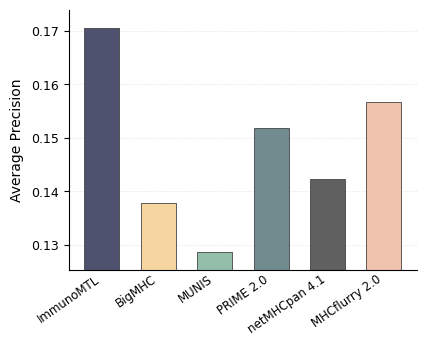

Saved fig5_a.{pdf,png}


In [306]:
# ── Panel a — AP bar chart ─────────────────────────────────────────────────────

MTL_MRNA = f'{PRED}/MTL/mRNA_predictions.csv'

MRNA_PRED_FILES = {
    'ImmunoMTL': (MTL_MRNA,
                  'score', False, None),
    'BigMHC':    (f'{PRED}/bigmhc/mRNA_bigmhc.csv',
                  'BigMHC_IM', False, MTL_MRNA),
    'MUNIS':     (f'{PRED}/munis/mRNA_munis_predictions.csv',
                  'score', False, None),
    'PRIME2':    (f'{PRED}/prime2/mRNA_prime.csv',
                  'PRIME_rank', True, None),
    'netMHCpan': (f'{PRED}/netMHCpan/mRNA_netMHCpan.csv',
                  'EL_Rank', True, None),
    'MHCflurry': (f'{PRED}/mhcflurry/mRNA_mhcflurry.csv',
                  'mhcflurry_presentation_percentile', True, None),
}

def load_pred_a(path, score_col, negate, label_source):
    df = pd.read_csv(path)
    for old, new in [('pep', 'Peptide'), ('mhc', 'MHC')]:
        if old in df.columns and new not in df.columns:
            df = df.rename(columns={old: new})
    if label_source is not None:
        ref = pd.read_csv(label_source)[['Peptide', 'MHC', 'Label']]
        df  = df.merge(ref, on=['Peptide', 'MHC'], how='left')
    yp = df[score_col].values.astype(float)
    if negate:
        yp = -yp
    yt = df['Label'].values.astype(float)
    mask = ~(np.isnan(yt) | np.isnan(yp))
    return yt[mask], yp[mask]

ap_vals = {}
for model in MRNA_MODELS:
    path, col, neg, lsrc = MRNA_PRED_FILES[model]
    yt, yp = load_pred_a(path, col, neg, lsrc)
    ap_vals[model] = average_precision_score(yt, yp)
    print(f'  {DISPLAY[model]:<16}  AP={ap_vals[model]:.4f}')

def bar_ylim(vals, pad=0.08):
    lo   = min(vals.values())
    hi   = max(vals.values())
    span = hi - lo if hi > lo else hi * 0.2
    return (max(0, lo - span * pad), hi + span * pad)

fig, ax = plt.subplots(figsize=(4.2, 4.2))
fig.subplots_adjust(bottom=0.30, top=0.92, left=0.14, right=0.97)
for i, model in enumerate(MRNA_MODELS):
    ax.bar(i, ap_vals[model], width=0.62,
           color=COLORS[model], edgecolor='#444444', linewidth=0.6, zorder=3)
ax.set_xticks(range(len(MRNA_MODELS)))
ax.set_xticklabels([DISPLAY[m] for m in MRNA_MODELS],
                   rotation=35, ha='right', fontsize=8.5)
ax.tick_params(axis='x', length=0, pad=2)
ax.set_ylim(*bar_ylim(ap_vals))
ax.set_ylabel('Average Precision', fontsize=10, labelpad=5, color='#000000')
ax.spines[['top', 'right']].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['left'].set_zorder(4)
ax.spines['bottom'].set_linewidth(0.8)
ax.spines['bottom'].set_zorder(4)
ax.tick_params(axis='y', labelsize=9, width=0.8)
ax.yaxis.grid(True, linestyle=':', linewidth=0.6, color='#DDDDDD', zorder=0)
ax.set_axisbelow(True)

plt.savefig(os.path.join(FIG_DIR, 'fig5_a.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'fig5_a.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved fig5_a.{pdf,png}')


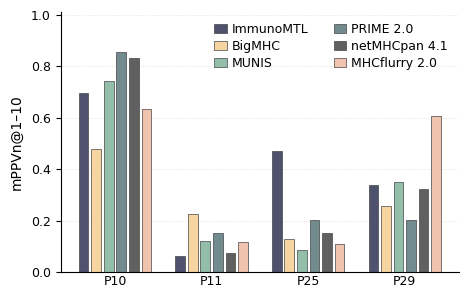

Saved fig5_c.{pdf,png}


In [307]:
# ── Panel c — mPPV, grouped bar chart (4 patient groups × 6 model bars) ───────

n_models   = len(MRNA_MODELS)
n_patients = len(PATIENTS)
bw         = 0.10                        # single bar width
gap        = 0.03                        # gap between bars within a group
step       = bw + gap
offsets    = np.arange(n_models) * step
offsets   -= offsets.mean()              # centre the group around each tick

fig, ax = plt.subplots(figsize=(4.8, 4.2))
fig.subplots_adjust(bottom=0.30, top=0.92, left=0.14, right=0.97)

x_groups = np.arange(n_patients)

for j, model in enumerate(MRNA_MODELS):
    xpos  = x_groups + offsets[j]
    yvals = [mppv[model][p] for p in PATIENTS]
    ax.bar(xpos, yvals, width=bw,
           color=COLORS[model], edgecolor='#444444', linewidth=0.5, zorder=3,
           label=DISPLAY[model])

top_c = max(mppv[m][p] for m in MRNA_MODELS for p in PATIENTS) * 1.18
ax.set_xticks(x_groups)
ax.set_xticklabels([PLABEL[p] for p in PATIENTS], fontsize=9)
ax.tick_params(axis='x', length=0, pad=2)
ax.set_ylim(0, top_c)
ax.set_ylabel('mPPVn@1–10', fontsize=10, labelpad=5, color='#000000')
ax.spines[['top', 'right']].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['left'].set_zorder(4)
ax.spines['bottom'].set_linewidth(0.8)
ax.spines['bottom'].set_zorder(4)
ax.tick_params(axis='y', labelsize=9, width=0.8)
ax.yaxis.grid(True, linestyle=':', linewidth=0.6, color='#DDDDDD', zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=9, frameon=False, ncol=2,
          handlelength=1.0, handletextpad=0.4, labelspacing=0.3)

plt.savefig(os.path.join(FIG_DIR, 'fig5_c.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'fig5_c.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved fig5_c.{pdf,png}')


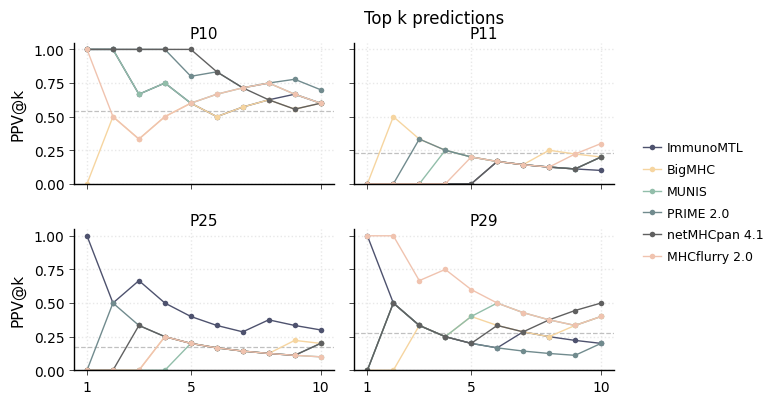

Saved fig5_b.{pdf,png}


In [312]:
# ── Panel b — PPV@k=1–10 line curves, 2×2 subplots ────────────────────────────

ks = list(range(1, K_MAX + 1))

fig, axes = plt.subplots(2, 2, figsize=(9, 4.2),
                         sharex=True, sharey=True)
fig.subplots_adjust(left=0.10, right=0.70, top=0.88, bottom=0.10,
                    wspace=0.08, hspace=0.32)

for idx, (ax, p) in enumerate(zip(axes.flat, PATIENTS)):
    for model in MRNA_MODELS:
        ax.plot(ks, ppv_data[model][p], '-o',
                color=COLORS[model], lw=1.0, ms=4,
                markeredgewidth=0, zorder=2)

    ax.axhline(pat[p]['Label'].mean(), ls='--', color='#C0C0C0', lw=0.9, zorder=1)
    ax.set_title(PLABEL[p], fontsize=11, pad=3)
    ax.set_xlim(0.5, K_MAX + 0.5)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([1, 5, 10])
    ax.set_yticks([0.00, 0.25, 0.50, 0.75, 1.00])
    ax.tick_params(labelsize=10, width=0.5)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['left'].set_linewidth(1)
    ax.spines['bottom'].set_linewidth(1)
    ax.xaxis.grid(True, linestyle=':', linewidth=1, color='#E8E8E8', zorder=0)
    ax.yaxis.grid(True, linestyle=':', linewidth=1, color='#E8E8E8', zorder=0)
    ax.set_axisbelow(True)

    row, col = divmod(idx, 2)
    if col == 0:
        ax.set_ylabel('PPV@k', fontsize=11, labelpad=6)

fig.suptitle('Top k predictions', fontsize=12, y=0.96)

handles = [Line2D([0], [0], color=COLORS[m], lw=1.0, marker='o', ms=4,
                  markeredgewidth=0, label=DISPLAY[m])
           for m in MRNA_MODELS]
fig.legend(handles=handles, loc='center left', bbox_to_anchor=(0.72, 0.50),
           fontsize=9, frameon=False,
           handlelength=1.4, labelspacing=0.7, handletextpad=0.5)

plt.savefig(os.path.join(FIG_DIR, 'fig5_b.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'fig5_b.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved fig5_b.{pdf,png}')


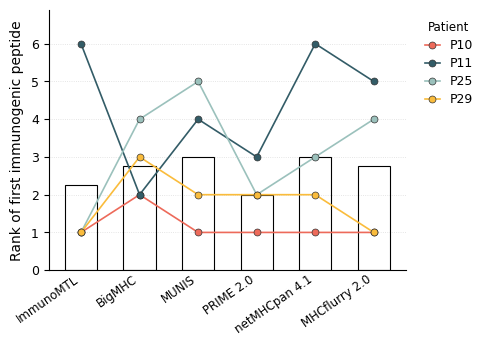

Saved fig5_d.{pdf,png}


In [309]:
# ── Panel d — First-hit rank (unfilled bars, axis-weight border + per-patient lines)

means = {model: np.nanmean([fhit_data[model][p] for p in PATIENTS])
         for model in MRNA_MODELS}

fig, ax = plt.subplots(figsize=(5.5, 4.2))
fig.subplots_adjust(bottom=0.30, top=0.92, left=0.13, right=0.78)

x = np.arange(len(MRNA_MODELS))

# Unfilled bars, black border matching spine weight (0.8)
for i, model in enumerate(MRNA_MODELS):
    ax.bar(i, means[model], width=0.55,
           facecolor='none', edgecolor='#000000', linewidth=0.8, zorder=3)

# Per-patient lines & dots
for p, pc in zip(PATIENTS, PATIENT_COLORS):
    ys = [fhit_data[m][p] for m in MRNA_MODELS]
    ax.plot(x, ys, '-o', color=pc, ms=5, lw=1.2, zorder=4,
            markeredgecolor='#333333', markeredgewidth=0.5, label=PLABEL[p])

all_ranks = [fhit_data[m][p] for m in MRNA_MODELS for p in PATIENTS
             if not np.isnan(fhit_data[m][p])]
ax.set_ylim(0, max(all_ranks) * 1.15)

ax.set_xticks(x)
ax.set_xticklabels([DISPLAY[m] for m in MRNA_MODELS],
                   rotation=35, ha='right', fontsize=8.5)
ax.tick_params(axis='x', length=0, pad=2)
ax.set_ylabel('Rank of first immunogenic peptide', fontsize=10, labelpad=5,
              color='#000000')
ax.spines[['top', 'right']].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.tick_params(axis='y', labelsize=9, width=0.8)
ax.yaxis.grid(True, linestyle=':', linewidth=0.6, color='#DDDDDD', zorder=0)
ax.set_axisbelow(True)
ax.legend(title='Patient', fontsize=9, title_fontsize=8.5, frameon=False,
          loc='upper left', bbox_to_anchor=(1.02, 1.0),
          handlelength=1.2, labelspacing=0.4)

plt.savefig(os.path.join(FIG_DIR, 'fig5_d.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'fig5_d.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved fig5_d.{pdf,png}')
